El conjunto de datos se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un dataset con un conjunto de datos sobre calidad del aire. El conjunto de datos contiene 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

### Análisis descriptivo de los datos


In [1]:
import pandas as pd

filename = "./AirQualityUCI.csv"
data = pd.read_csv(
    filename, 
    delimiter=";",
    decimal=",",
    #na_values=-200,
    usecols=lambda c: c not in ["Unnamed: 15", "Unnamed: 16"]
)

In [3]:
#len(data)
data.describe()
#print(len(data)-data.count())

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


Si vemos la longitud del dataset usando el comando $len(data)$ nos dice que el dataset tiene <b>9471</b> filas.
<br>
Pero el comando $data.count()$ así como $data.describe()$ devuelven un total de <b>9357</b> filas, ya que no tienen en cuenta las <b>114 filas vacías</b> que contiene el dataset.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


El comando $data.info()$ nos dicen que las dos primeras columnas son de tipo <b>object</b> y el resto de tipo <b>float</b>.
<br>
Esto sucede porque Pandas carga las columnas "Date" y "Time" como <b>object</b> en lugar de usar tipos fecha/hora, de igual forma que convierte automáticamente a <b>float</b> las columnas <b>int</b> que contienen valores nulos ($NaN$).

Según la descripción del dataset que podemos encontrar en https://archive.ics.uci.edu/dataset/360/air+quality:
<br>Categóricas:
- <b>Time
- <b>PT08.S1(CO)</b>: hourly averaged sensor response (nominally CO targeted)
- <b>PT08.S2(NMHC)</b>: hourly averaged sensor response (nominally NMHC targeted)
- <b>PT08.S3(NOx)</b>: hourly averaged sensor response (nominally NOx targeted)
- <b>PT08.S4(NO2)</b>: hourly averaged sensor response (nominally NO2 targeted)
- <b>PT08.S5(O3)</b>: hourly averaged sensor response (nominally O3 targeted)

Continuas:
- <b>C6H6(GT)</b>: True hourly averaged Benzene concentration in microg/m^3 (reference analyzer)
- <b>T</b>: Temperature
- <b>RH</b>: Relative Humidity
- <b>AH</b>: Absolute Humidity

Pero viendo los datos que contienen las columnas del dataset, todas excepto Date y Time, podrían considerarse continuas (<b>2 categóricas</b> y <b>13 continuas</b>).

In [8]:
data.isnull().values.any()

True

Para ver si existe algún valor nulo en el dataset podemos usar el comando $data.isnull().values.any()$

In [9]:
## ¿cuál es la variable respuesta?¿de qué tipo es?
objetivo = "PT08.S1(CO)"
#objetivo = "C6H6(GT)"
#objetivo = "PT08.S5(O3)"

El dataset contiene mediciones indicadoras de la calidad del aire, por tanto la variable respuesta podría ser la concentración de alguno de estos indicadores:
- <b>CO(GT)</b>: Concentración de monóxido de carbono
- <b>NMHC(GT)</b>: Concentración de hidrocarburos
- <b>C6H6(GT)</b>: Concentración de benzeno
- <b>NOx(GT)</b>: Concentración de óxido de nitrógeno
- <b>NO2(GT)</b>: Concentración de dióxido de nitrógeno

Entre estos indicadores podríamos pensar en usar por ejmplo la variable CO(GT) pero, como veremos más adelante, el hecho que todas estas variables, excepto C6H6(GT), presentan un gran número de valores faltantes, las hacen no adecuadas como variables objetivo.
<br><br>
En lugar de usar CO(GT) usaremos <b>PT08.S1(CO)</b> como variable respuesta en este problema de regresión lineal, ya que vemos que tiene una alta correlación con CO(GT), de 0.88.

In [ ]:
¿cómo es la distribución de las variables, CO, NOx y NO2? 

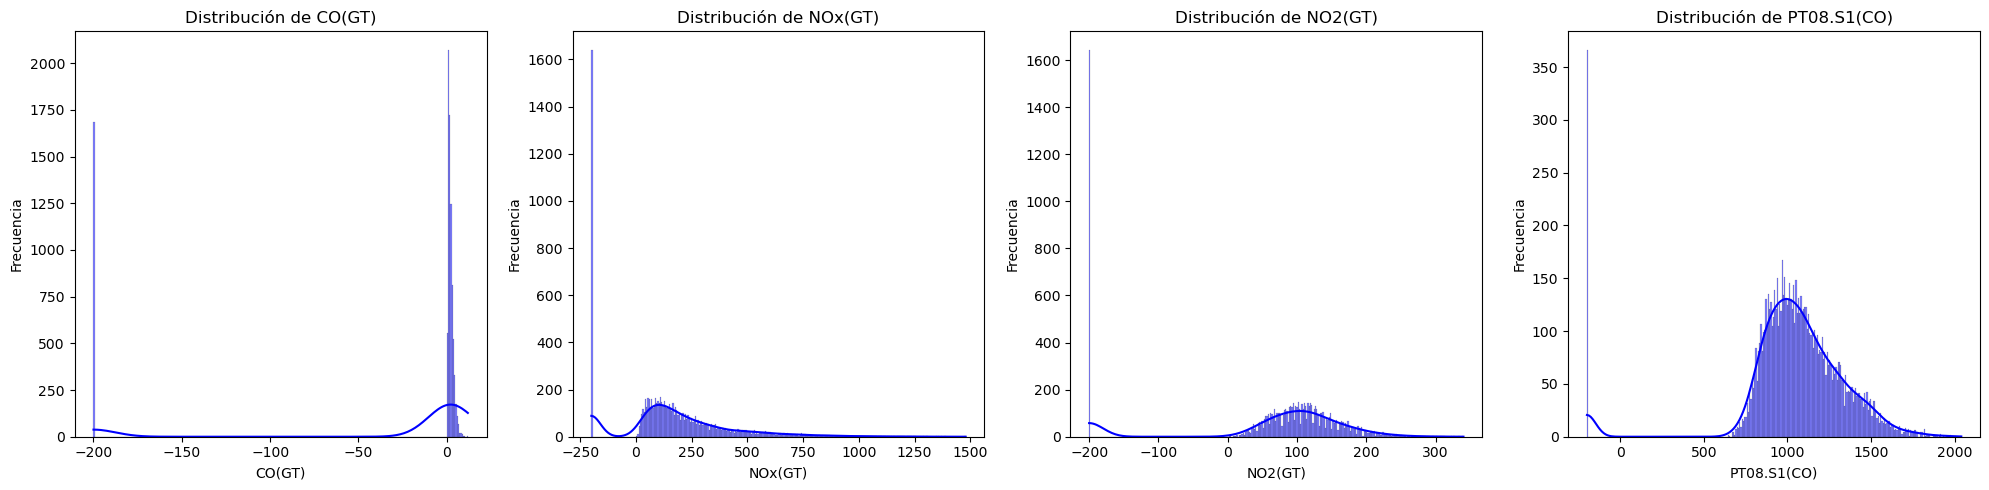

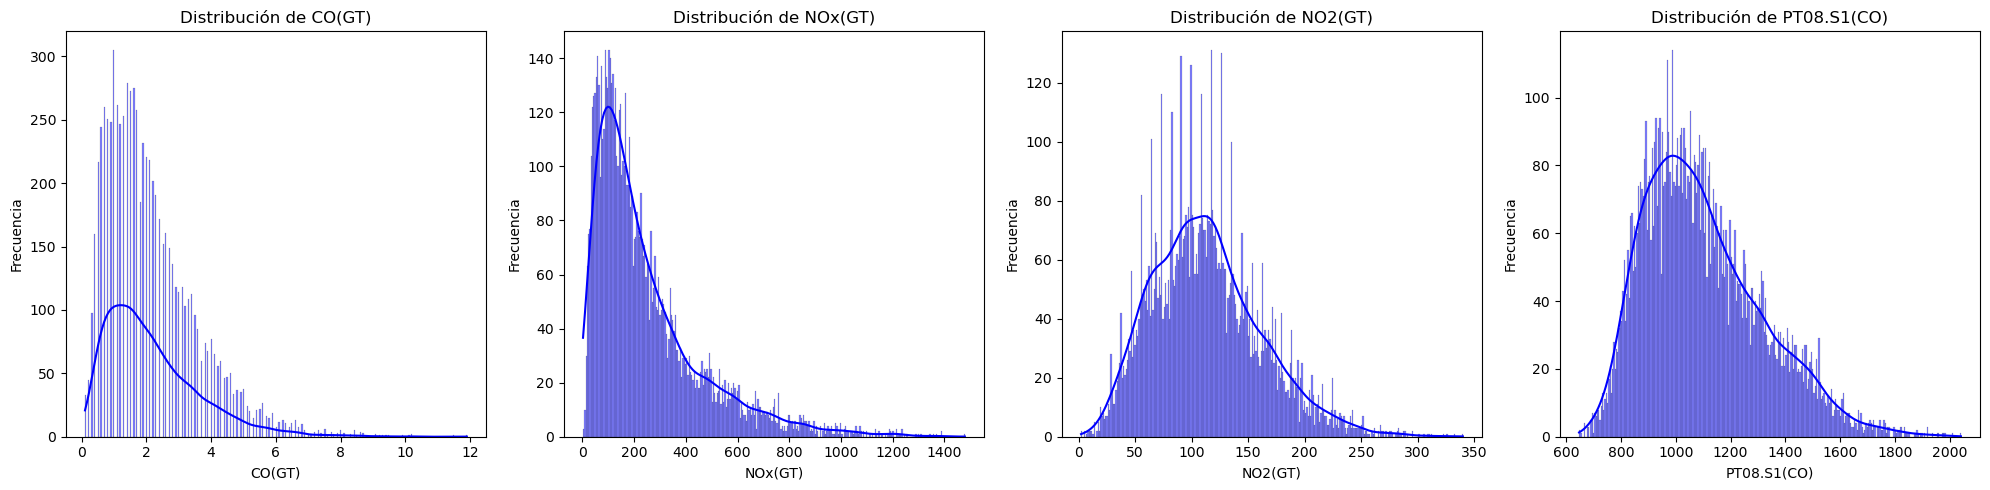

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distributions(dataset, variables):
    plt.figure(figsize=(20, 5))

    for i, var in enumerate(variables, start=1):
        plt.subplot(1, len(variables), i)
        sns.histplot(dataset[var], kde=True, bins=300, color="blue")
        plt.title(f"Distribución de {var}")
        plt.xlabel(var)
        plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

variables = ["CO(GT)", "NOx(GT)", "NO2(GT)", "PT08.S1(CO)"]
#variables = ["C6H6(GT)", "PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S5(O3)"]

# Variables en el dataset original
plot_distributions(data, variables)

data_clean = data.copy()
data_clean.replace(-200, "nan", inplace=True)
data_clean.replace("-200,0", "nan", inplace=True)
data_clean.drop(columns=["Date", "Time"], inplace=True)

for col in data_clean.columns:
    data_clean[col] = pd.to_numeric(data_clean[col], errors="coerce")

# Variables en el dataset sin valores -200
plot_distributions(data_clean, variables)

In [13]:
data_clean.isnull().sum().sort_values(ascending=False)

NMHC(GT)         8557
CO(GT)           1797
NO2(GT)          1756
NOx(GT)          1753
PT08.S1(CO)       480
C6H6(GT)          480
PT08.S2(NMHC)     480
PT08.S3(NOx)      480
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

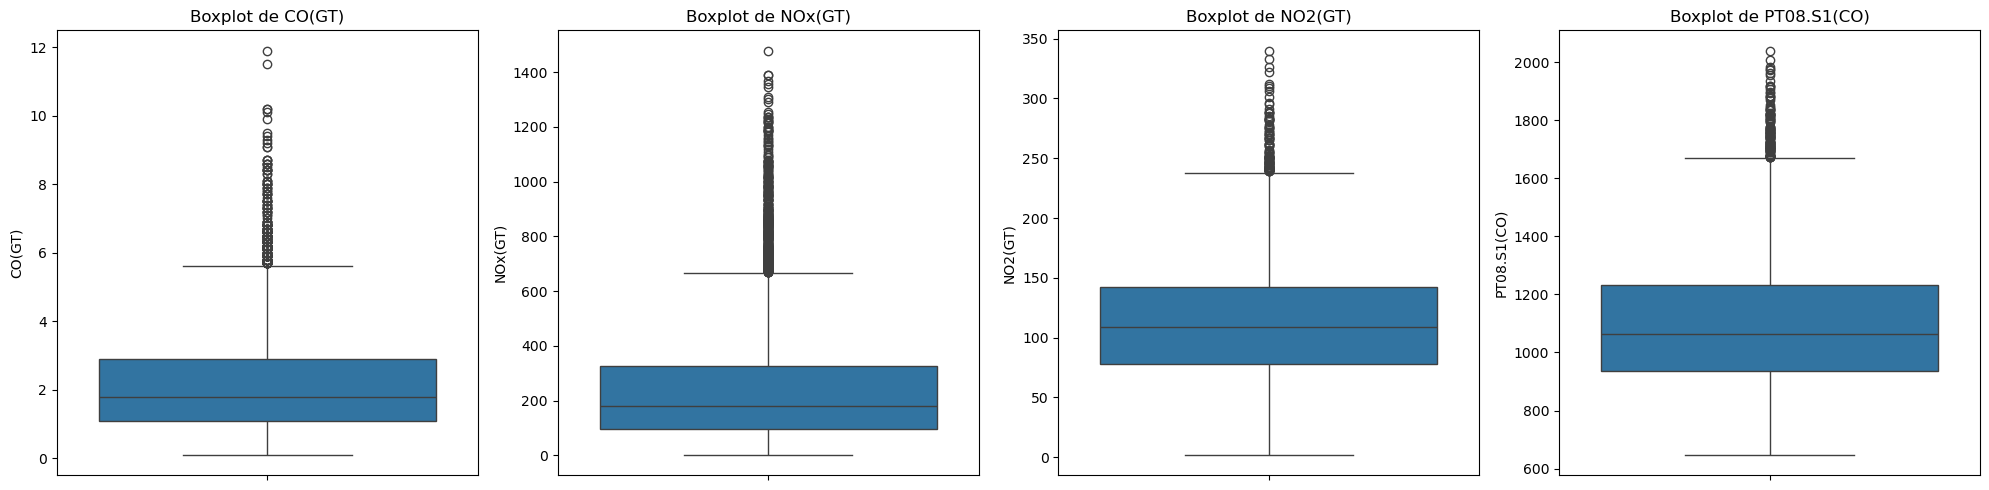

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxes(dataset, variables):
    plt.figure(figsize=(20, 5))

    for i, var in enumerate(variables, start=1):
        plt.subplot(1, len(variables), i)
        sns.boxplot(data_clean[var])
        plt.title(f"Boxplot de {var}")

    plt.tight_layout()
    plt.show()

plot_boxes(data_clean, variables)

Las tres variables contienen muchos valores faltantes (_NaN_) y datos anómalos que corresponden a valores faltantes que se han marcado con un -200 (los vemos en el pico inicial en la primera fila de gráficas de deistribución).
<br><br>
Una vez eliminados los valores anómalos, vemos que tanto la gráfica de distribución de <b>CO(GT)</b> como de <b>NOx(GT)</b> son asimétricas, mostrando una alta concentración de valores bajos y una disminución progresiva hacia valores más altos. Esto indicaría que los valores bajos de CO y NOx son más habituales, mientras que valores altos de alguno de estos dos componentes no son tan frecuentes y podrían indicar un episodio de contaminación en el aire.
<br><br>
La gráfica de distribución de <b>NO2(GT)</b> no es tan asimétrica como las anteriores, con la mayoría de los valores concentrados en un rango más central de la gráfica.
<br><br>
Usando el suficiente número de bins, podemos ver claramente que <b>CO(GT)</b> tiene muchos valores faltantes a lo largo de su distribución, lo cual no la hace apta como variable objetivo del modelo de regresión.
<br><br>
Finalmente, los diagramas de cajas nos muestran que las tres variables contienen abundantes valores outliers, sobretodo en la variable NO2(GT).

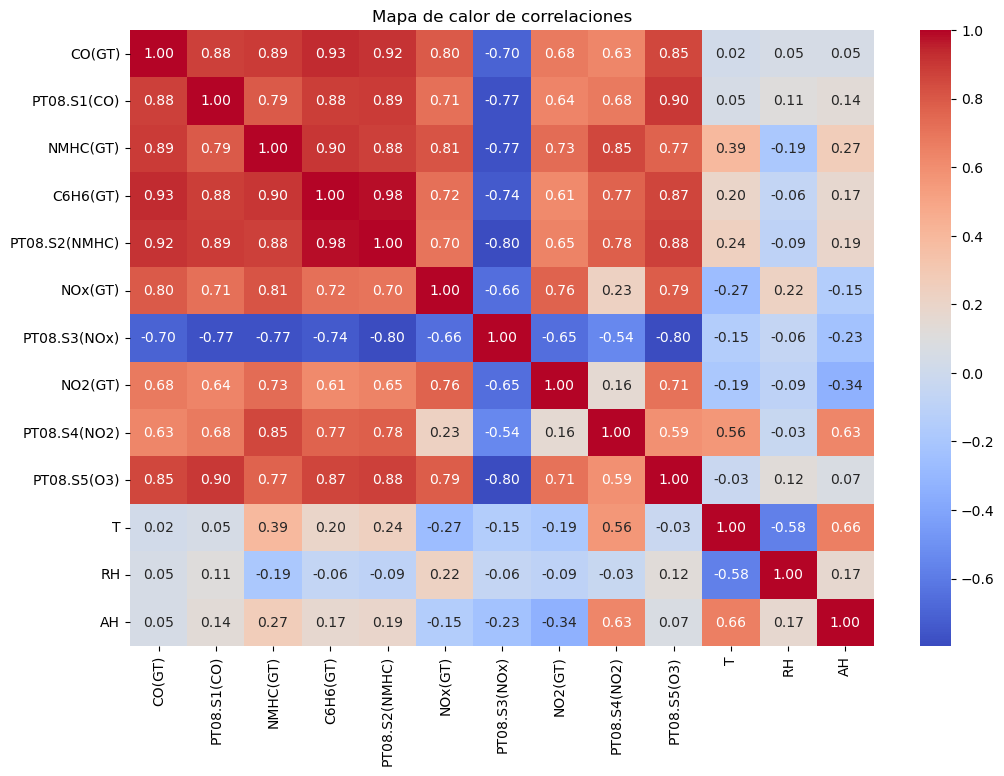

In [16]:
correlation_matrix = data_clean.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Mapa de calor de correlaciones")
plt.show()

El mapa de calor de correlaciones nos muestra que las variables <b>C6H6(GT)</b> y <b>PT08.S2(NMHC)</b> tienen una correlación muy fuerte entre ellas, casi directa (0.98).
<br>
<b>CO(GT)</b> también tienen una alta correlación con <b>C6H6(GT)</b> (0.93) y <b>PT08.S2(NMHC)</b> (0.92).
<br>
Por otro lado, la variable <b>PT08.S3(NOx)</b> muestra una relación negativa con todas las otras variables, en especial con <b>PT08.S2(NMHC)</b> y <b>PT08.S5(O3)</b> (-0.80).

In [18]:
target_correlations = correlation_matrix[objetivo]
most_correlated = target_correlations.drop(objetivo).sort_values(ascending=False).head(4)
print(most_correlated)

PT08.S5(O3)      0.899324
PT08.S2(NMHC)    0.892964
C6H6(GT)         0.883795
CO(GT)           0.879288
Name: PT08.S1(CO), dtype: float64


Las tres variables más correlacionadas con la variable objetivo <b>PT08.S1(CO)</b> son:
- <b>PT08.S5(O3)</b> (0.93)
- <b>PTO8.S2(NMHC)</b> (0.91)
- <b>C6H6(GT)</b> (0.89)

Todas las variables están correlacionadas, aunque algunos valores son muy bajos, por ejemplo:
- <b>RH</b> (Humedad Relativa) y <b>AH</b> (Humedad Absoluta) con prácticamente el resto de variables.
- <b>PTO8.S4(NO2)</b> con <b>NO2(GT)</b> (0.16) y <b>NOx(GT)</b> (0.23).

- Hay que tratar tanto los valores faltantes (_NaN_) como valores anómalos marcados con -200.
- El alto número de valores faltantes en la variable CO(GT) la descarta como variable objetivo.
- La fuerte correlación de CO(GT) con PTO8.S1(CO) nos hace pensar en esta última como una buena candidataa variable objetivo.
- Habría que ver cómo afectan los valores outliers.
- Dada la fuerte correlación de <b>PT08.S5(O3)</b> y <b>PTO8.S2(NMHC)</b> con la variable objetivo <b>PTO8.S1(CO)</b>, estos puede ser buenos predictores en un modelo de regresión lineal.
- La variable <b>PTO8.S3(NOx)</b> tiene un comportamiento atípico, ya que muestra una correlación negativa con todas las demás variables, lo que sugiere que está midiendo un fenómeno inversamente relacionado con los contaminantes ambientales que explican las otras variables.
- Dada la distribución asimétrica de la variable objetivo PTO8.S1(CO), deberíamos optar por un muestreo aleatorio estratificado para dividir el dataset en los dos subconjuntos (train y test). 

### Regresión

In [21]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from pandas import DataFrame

scaler = StandardScaler()

In [22]:
# separar datos de entrenamiento y test

In [67]:
from sklearn.model_selection import train_test_split

predictor = "PT08.S5(O3)"

scaler.fit(data_clean)
mscaled_data = pd.DataFrame(scaler.transform(data_clean), columns = data_clean.columns)
data_filtered = mscaled_data.dropna(subset=[objetivo, predictor])

X = data_filtered[[objetivo]]

X_train, X_test = train_test_split(X, test_size=0.20, random_state=42)

In [ ]:
data_filtered.isnull().sum().sort_values(ascending=False)

In [ ]:
# Variable que mejor va a realizar la predicción

In [69]:
#predictor = "PT08.S2(NMHC)"
predictor = "PT08.S5(O3)"
#predictor = "C6H6(GT)"

y = data_filtered[predictor]

y_train, y_test = train_test_split(y, test_size=0.20, random_state=42)

In [ ]:
# entrenar el modelo

In [71]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Valores aprendidos por el modelo para los parámetros

In [73]:
print(f"Intersección (Intercept): {linear_model.intercept_:.4f}")
print(f"Pendiente (Slope): {linear_model.coef_[0]:.4f}")

Intersección (Intercept): -0.0019
Pendiente (Slope): 0.8991


Estos parámetros se usan para calcular la relación entre los predictores y el resultado.
<br>
Dada la combinación lineal de predictores, que se describe como:
<br>
_f(x) = y = b0 + b1 · X + e_
<br>
- <b>b0</b> (intercept) representa el valor de y cuando X=0.<br>Indica el valor esperado de la variable objetivo PT08.S1(CO) cuando la variable predictora PT08.S5(O3) está en su valor promedio.
- <b>b1</b> (slope) es el coeficiente (pendiente) asociado a X.<br>Indica cómo cambia la variable objetivo en función de la variable predictora.

In [ ]:
# Predicciones para el conjunto de datos de test

In [76]:
y_pred = linear_model.predict(X_test)

El diagrama de dispersión nos muestra, de forma visual, la relación entre valores reales y valores predichos.
<br>
Y el análisis de residuos nos muestra diferencias entre los valores reales del dataset y los valores estimados calculados con la ecuación de regresión.

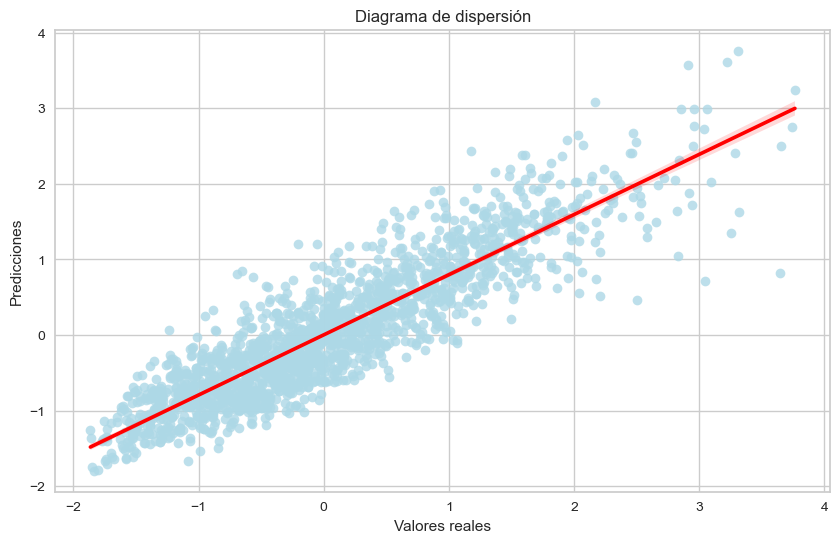

       Real  Predicción
0  0.359115    0.189290
1  2.145985    2.107013
2  0.253710    0.073316
3 -0.993585   -0.800636
4 -0.180459   -0.249756
5 -0.147834   -0.287034
6 -0.516752   -0.481705
7 -0.717524   -0.854481
8  3.097142    2.028316
9 -1.362504   -0.742648


In [78]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={"color": "lightblue"}, line_kws={"color": "red"})
plt.title("Diagrama de dispersión")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.show()

resultados = pd.DataFrame({
    "Real": y_test,
    "Predicción": y_pred
}).reset_index(drop=True)

print(resultados.head(10))

C:\Users\ivanm\anaconda3\envs\TAA\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


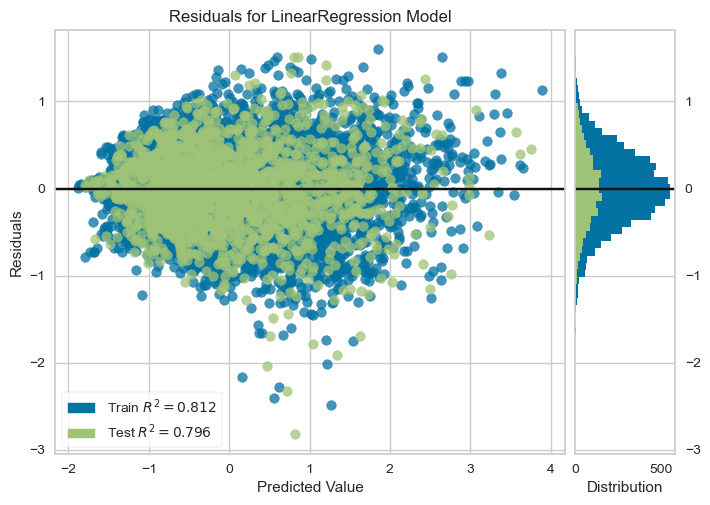

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [79]:
from yellowbrick.regressor import ResidualsPlot

visualizer = ResidualsPlot(linear_model)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.poof()

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Error Medio Absoluto (MAE): {mae:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

Error Medio Absoluto (MAE): 0.35
Error Cuadrático Medio (MSE): 0.21
Raíz del Error Cuadrático Medio (RMSE): 0.45
Coeficiente de Determinación (R²): 0.80


- <b>MAE</b>: Mean Absolute Error, es una medida de la magnitud promedio de los errores en las predicciones, calculada como la diferencia absoluta promedio entre las predicciones del modelo y los valores reales. Es fácil de interpretar, ya que está representada en las unidades originales de la variable objetivo.
- <b>R²</b>: Coeficiente de determinación, puede interpretarse como el porcentaje de información del dataset que el modelo es capaz de explicar.
- <b>MSE</b>: Mean Squared Error, mide el promedio de los cuadrados de las diferencias entre los valores reales y los valores predichos por el modelo.
- <b>RMSE</b>: Root Mean Square Error, al estar en la misma escala que la variable objetivo, nos da una idea del error real que está cometiendo el modelo.
<br>
Tanto MSE como RMSE penalizan errores grandes, lo cual los hace útiles para detectar grandes desviaciones.
<br>
Si el error es pequeño y el R² es cercano a 1, el modelo está funcionando correctamente.
<br>
En este caso, no parece que el modelo esté mostrando un desempeño excesivamente bueno.

In [82]:
errores = y_test - y_pred
print("Errores individuales:", errores[:10])

Errores individuales: 1180    0.169825
9025    0.038972
5360    0.180394
7997   -0.192950
4684    0.069297
2414    0.139200
1515   -0.035047
5205    0.136957
6669    1.068826
4303   -0.619855
Name: PT08.S5(O3), dtype: float64


Segundo modelo que hará uso de una regresión lineal múltiple con todas las variables del dataset.

In [83]:
predictores = [col for col in data_clean.columns if col not in [objetivo]] # R2 = 0.63
#predictores = ["PT08.S5(O3)", "PT08.S2(NMHC)", "C6H6(GT)", "NMHC(GT)"] # R2 = 0.82

mscaler = StandardScaler()
mscaler.fit(data_clean)
mscaled_data = pd.DataFrame(mscaler.fit_transform(data_clean), columns=data_clean.columns)

mdata_filtered = mscaled_data.dropna(subset=[objetivo] + predictores)

Xm = mdata_filtered[[objetivo]]
ym = mdata_filtered[predictores]

Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.20, random_state=42)

multilinear_model = LinearRegression()
multilinear_model.fit(Xm_train, ym_train)

LinearRegression()

In [84]:
ym_pred = multilinear_model.predict(Xm_test)

Ambos modelos tienen el mismo error medio absoluto (MAE).
El modelo de múltiples variables tiene un error cuadrático medio (MSE) y RMSE ligeramente superior, aunque la diferencia en sus coeficientes de determinación es significativamente inferior en el segundo modelo.
Por lo tanto, podemos decir que el primer modelo de regresión lineal simple ofrece mejores resultados que el modelo de múltiples variables.

In [85]:
mae = mean_absolute_error(ym_test, ym_pred)
mse = mean_squared_error(ym_test, ym_pred)
rmse = np.sqrt(mse)
r2 = r2_score(ym_test, ym_pred)

print(f"Error Medio Absoluto (MAE): {mae:.2f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

Error Medio Absoluto (MAE): 0.35
Error Cuadrático Medio (MSE): 0.22
Raíz del Error Cuadrático Medio (RMSE): 0.47
Coeficiente de Determinación (R²): 0.63


#### Regresión con árboles de decisión

El algortimo de DTRegressor necesitar ajustar una serie de hiperparámetros para realizar las predicciones:

- <b>criterion</b>: Se usa para definir la función con la que medir la calidad de una división como, por ejemplo: minimizar error cuadrático (_squared_error_) minimizar error absoluto (_absolute_error_), etc.
- <b>splitter</b>: Define la estrategia utilizada para dividir los nodos: _best_, _random_
- <b>max_depth</b>: Define la profundidad máxima del árbol y así controlar la complejidad del modelo y prevenir sobreajustes.
- <b>min_samples_split</b>: Determina el número mínimo de muestras necesarias para dividir un nodo. Valores altors generan árboles menos complejos.
- <b>min_samples_leaf</b>: Determina el número mínimo de muestras necesarias para formar una hoja. Valores altos generalizan mejor.
- <b>max_features</b>: Es el número máximo de características que se deben considerar para encontrar la mejor división, ayudando así a reducir el tiempo de entrenamiento y a mitigar el sobreajuste.

min_impurity_decrease indica el valor de umbral mínimo de reducción de la impureza que se debe lograr para realizar una división, ayudando a controlar la inclusión de divisiones que no sean suficientemente significativas. Valores altos evitan la creación de divisiones con poca mejora, reduciendo así la complejidad del árbol.

Modelo de árboles de decisión donde, el criterio para realizar las particiones es _poisson_, la profundidad máxima de los árboles es 10, el número mínimo de ejemplos para realizar una partición es 10, el número mínimo de ejemplos para considerarlo una hoja es 2, y el número máximo de características son todas.

In [86]:
from sklearn.model_selection import train_test_split

data_filtered = data_clean.dropna(subset=[objetivo] + predictores)

X = data_filtered[predictores]
y = data_filtered[objetivo]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [87]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(
    criterion="poisson",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features=None
)

decision_tree.fit(X_train, y_train)

DecisionTreeRegressor(criterion='poisson', max_depth=10, min_samples_leaf=2,
                      min_samples_split=10)

In [88]:
y_pred = decision_tree.predict(X_test)

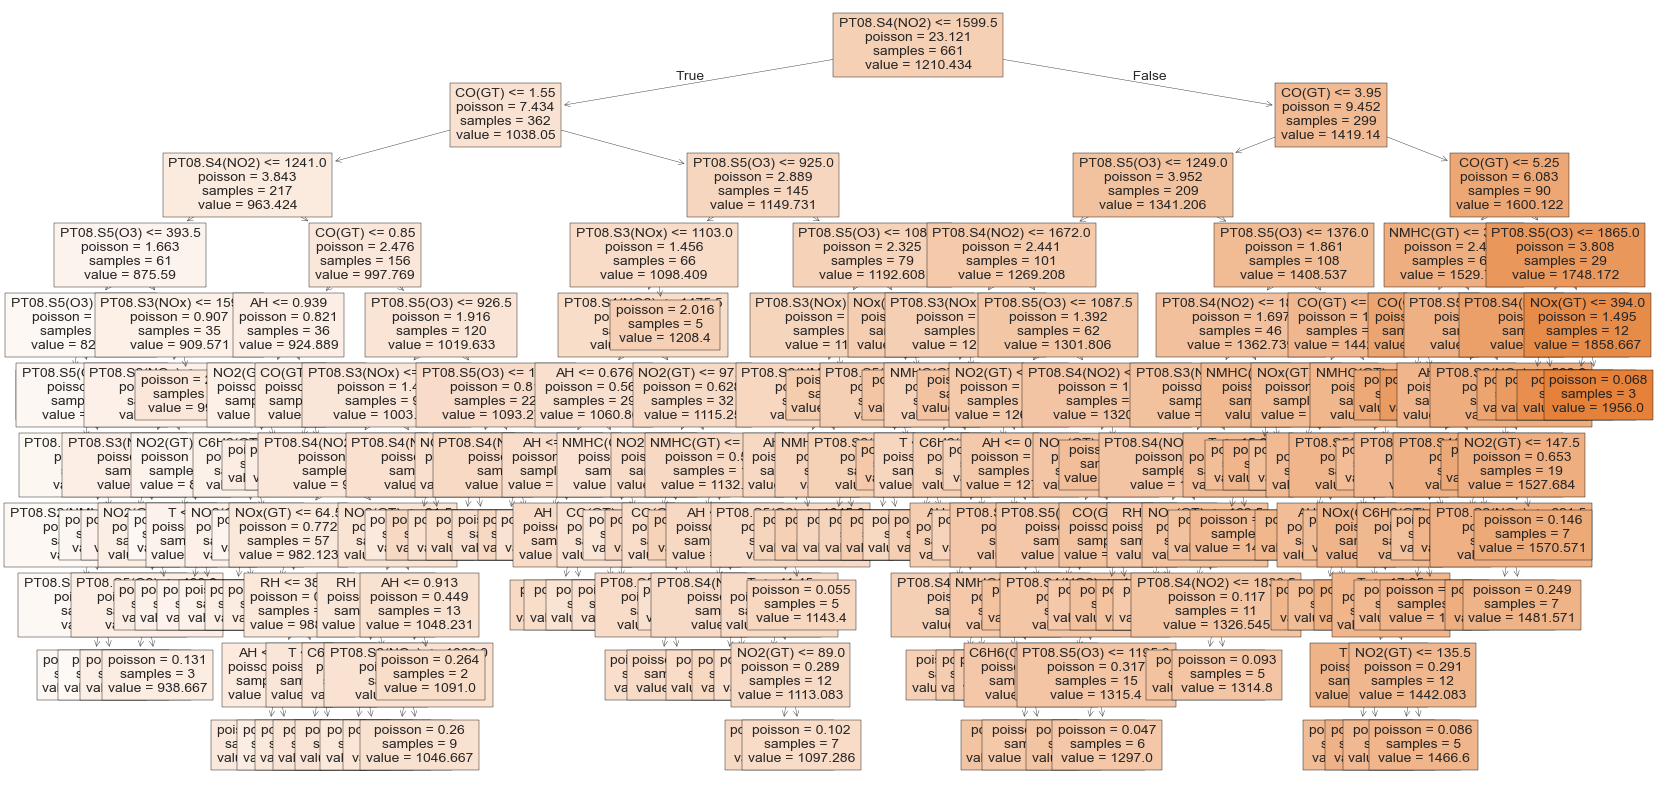

In [91]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(decision_tree, filled=True, feature_names=X.columns, fontsize=10)
plt.show()

In [92]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))

print(f"Error Medio Absoluto (MAE): {mae:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")
print(f"Root Mean Squared Logarithmic Error (RMSLE): {rmsle:.2f}")

Error Medio Absoluto (MAE): 51.64
Coeficiente de Determinación (R²): 0.93
Root Mean Squared Logarithmic Error (RMSLE): 0.05


Para verificar si existe overfitting podemos calcular el error y el Coeficiente de Determinación para los conjuntos de entrenamiento y de test y comprar los resultados.
<br>
En caso que el R² fuera muy alto para el conjunto de entrenamiento pero bajo para el conjunto de prueba, sería un indicador de la existencia de overfitting. Del mismo modo, si el error fuera bajo en el conjunto de entrenamiento pero bajo para el conjunto de prueba, también podría ser un indicador de overfitting. En este caso:
- En términos de errores relativos (RMSLE) parece que el modelo generaliza bien (0.06) en el conjunto de prueba.
- El R² en entrenamiento es muy alto (0.98), indicando que el modelo explica casi toda la variabilidad de los datos.
Sin embargo, el R² en prueba sigue siendo bastante bueno (0.93), y dado que la diferencia no es significativamente grande, no podemos concluir que exista overfitting.
- El MAE en prueba sí que es claramente más alto que en entrenamiento, lo que sugiere que el modelo tiene un peor desempeño de generalización, y puede ser un indicio de overfitting.



In [93]:
y_train_pred = decision_tree.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
rmsle_train = np.sqrt(mean_squared_log_error(y_train, y_train_pred))

print(f"MAE Entrenamiento: {mae_train:.2f}, MAE Prueba: {mae:.2f}")
print(f"R² Entrenamiento: {r2_train:.2f}, R² Prueba: {r2:.2f}")
print(f"RMSLE Entrenamiento: {rmsle_train:.2f}, RMSLE Prueba: {rmsle:.2f}")

MAE Entrenamiento: 22.38, MAE Prueba: 51.64
R² Entrenamiento: 0.98, R² Prueba: 0.93
RMSLE Entrenamiento: 0.02, RMSLE Prueba: 0.05


In [94]:
errores = y_test - y_pred
print("Errores individuales:", errores[:10])

Errores individuales: 317      -5.666667
1163    -77.750000
392      63.470588
482     166.714286
287    -181.857143
364      31.470588
1217    -46.833333
95      104.142857
385      15.666667
1164    -22.500000
Name: PT08.S1(CO), dtype: float64


- El modelo basado en árbol de decisión podría considerarse mejor si el enfoque principal es maximizar el R² (0.93), y su bajo RMSLE (0.06) sugiere que tiene un buen desempeño de generalización.
- El modelo de regresión lineal simple parece ofrecer un buen balance entre error y explicabilidad R² (0.80). Sus errores absolutos (MAE y RMSE) son menores, lo que lo hace más consistente en términos de predicción promedio.
- El modelo de árbol de decisión es peor en términos de MAE, con un valor significativamente mayor respecto a los modelos de regresión lineal, lo que indica que tiene errores absolutos más grandes en promedio y que sus predicciones absolutas son menos confiables. Podría sufrir de overfitting.
- Los modelos de regresión lineal son mejores al minimizar errores promedio absolutos, pero su capacidad para explicar la variabilidad de los datos es inferior.

**Comparativa**

El modelo de regresión lineal simple es rápido de entrenar, computacionalmente eficiente y sencillo de interpretar.
Mientras que el árbol de decisión es más costoso computacionalmente. Y, aunque maximiza la capacidad explicativa de los datos y puede capturar relaciones no lineales en los datos, habría que intentar optimizar sus hiperparámetros para reducir su MAE.
- Regresión lineal simple: R² = 0.80, MAE = 0.35, RMSLE = 0.45
- Regresión lineal múltiple: R² = 0.63, MAE = 0.35, RMSLE = 0.47
- Árbol de decisión: R² = 0.93, MAE = 0.52, RMSLE = 0.06